📍 DBSCAN (Density-Based Spatial Clustering) 기본 예제

🎯 1. DBSCAN이란?
DBSCAN은 밀도 기반 군집화 알고리즘이다.

👉 핵심 아이디어:

"데이터가 많이 모여 있는 곳(밀도 높은 곳)을 하나의 군집으로 본다"

🧠 2. 핵심 개념
✔ eps (입실론)
한 점 주변을 탐색하는 반경
✔ min_samples
군집으로 인정하기 위한 최소 데이터 개수

In [5]:
from sklearn.cluster import DBSCAN
import numpy as np

# 데이터
X = np.array([
    [1, 2], 
    [2, 2], 
    [2, 3],
    [8, 7], 
    [8, 8], 
    [7, 8],
    [25, 80]
])

# 모델 생성
# eps=2 한 점 기준으로 반경 2 안에 있는 점들을 이웃으로 본다
# min_samples=2 이웃이 2개 이상 있어야 군집으로 인정
# "반경 2 안에 친구가 2명 이상 있어야 우리 그룹!"

# 내부에서 하는 일
# 1.한 점 선택(내부 데이터중 하나)
# 2.eps 안에 몇 개 있는지 확인
# 3.min_samples 만족하면 군집 시작
# 4.연결된 점 계속 확장

# 먼저 점 p가 있다고 할때, 점 p에서 부터 거리 e (epsilon)내에 점이 m(minPts) 개 있으면 하나의 군집으로 인식한
# 출처: https://bcho.tistory.com/1205 [조대협의 블로그:티스토리]

model = DBSCAN(eps=2, min_samples=2)

# 학습
model.fit(X)

# 결과
labels = model.labels_
print(labels) #각 데이터의 군집 번호 반환

# ✔ Noise (이상치)
# 👉 아무 군집에도 속하지 않음

# 🧠 진짜 중요한 핵심
# DBSCAN 성능 = eps 선택이 80%

[ 0  0  0  1  1  1 -1]


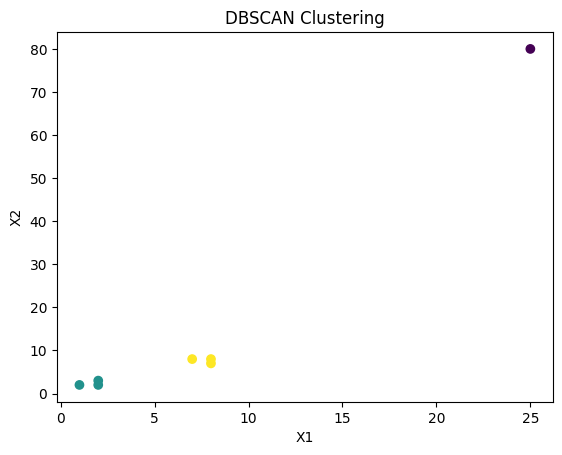

In [6]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0], X[:,1], c=labels)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("DBSCAN Clustering")
plt.show()

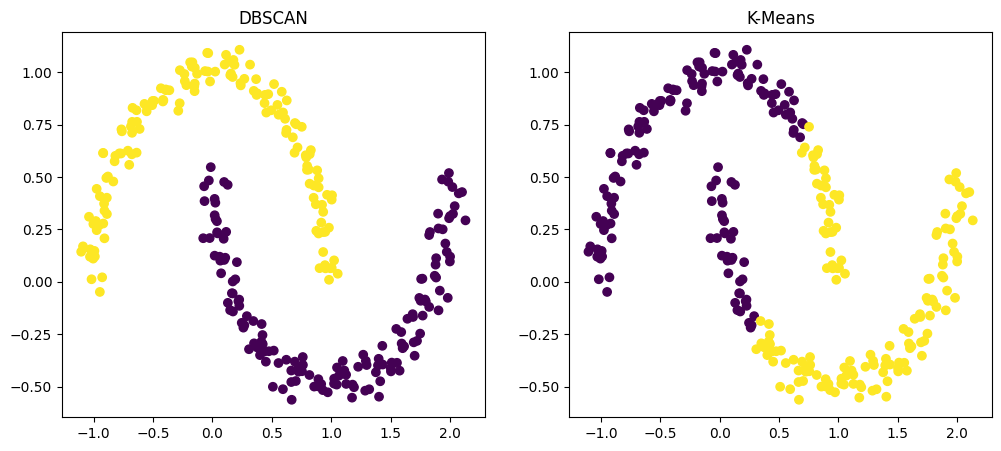

In [7]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN, KMeans
import matplotlib.pyplot as plt

# 1. 데이터 생성
X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

# 2. DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
db_labels = dbscan.fit_predict(X)

# 3. K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
km_labels = kmeans.fit_predict(X)

# 4. 시각화
plt.figure(figsize=(12, 5))

# DBSCAN 결과
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=db_labels)
plt.title("DBSCAN")

# K-Means 결과
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=km_labels)
plt.title("K-Means")

plt.show()


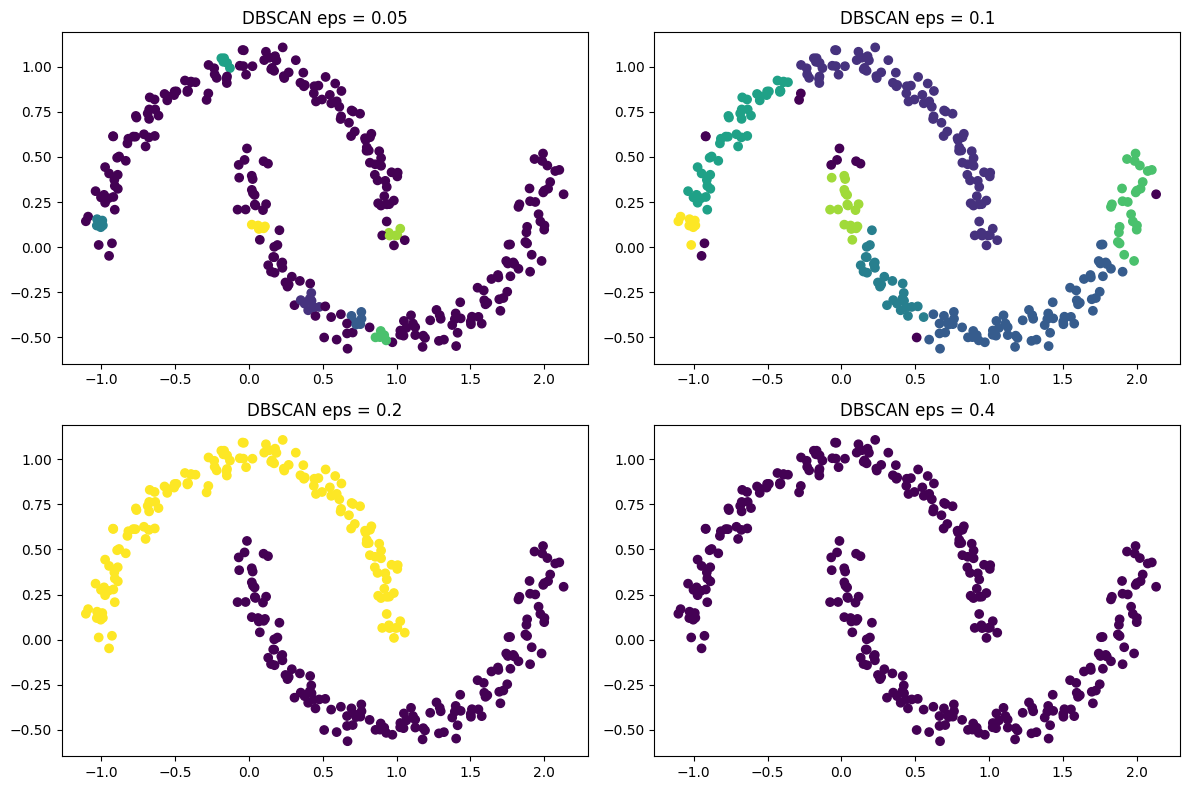

In [ ]:
from sklearn.cluster import DBSCAN

eps_values = [0.05, 0.1, 0.2, 0.4] # eps = “이 거리 안이면 친구”

plt.figure(figsize=(12,8))

for i, eps in enumerate(eps_values):
    model = DBSCAN(
        eps=eps,
        min_samples=5
    )
    labels = model.fit_predict(X)
    plt.subplot(2,2,i+1)
    plt.scatter(
        X[:,0],
        X[:,1],
        c=labels,
        cmap="viridis"
    )
    plt.title(f"DBSCAN eps = {eps}")

plt.tight_layout()
plt.show()

# eps 작다 → cluster 쪼개짐 + noise 증가
# eps 적당 → cluster 잘 형성
# eps 크다 → cluster 합쳐짐

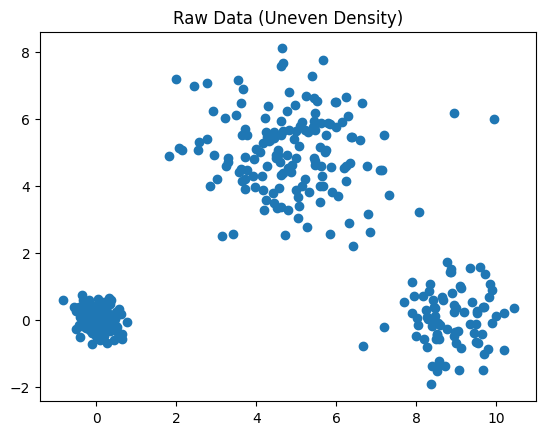


===== min_samples = 2 =====
cluster 개수: 5
noise 개수: 3

===== min_samples = 5 =====
cluster 개수: 4
noise 개수: 12

===== min_samples = 15 =====
cluster 개수: 3
noise 개수: 34


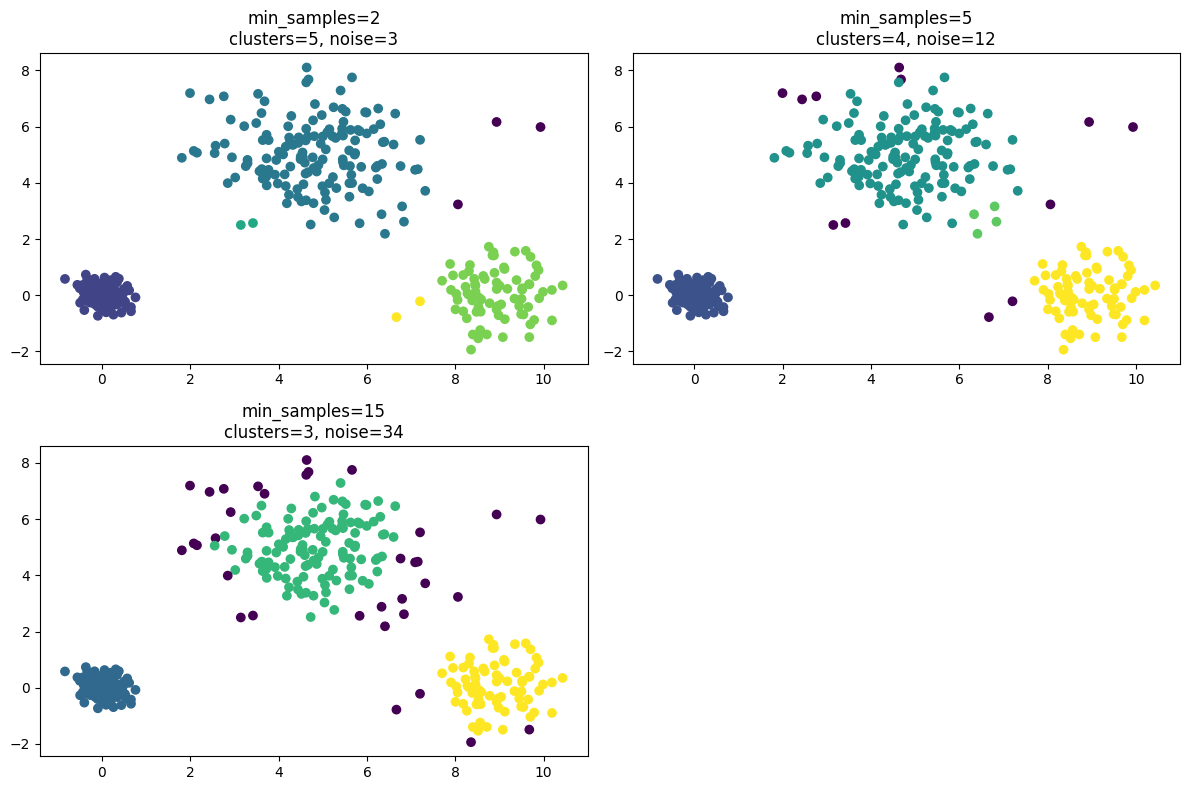

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN

# =========================
# 1️⃣ 데이터 생성 (밀도 다른 구조)
# =========================

X1, _ = make_blobs(
    n_samples=150,
    centers=[[0,0]],
    cluster_std=0.3,
    random_state=1
)

X2, _ = make_blobs(
    n_samples=150,
    centers=[[5,5]],
    cluster_std=1.2,
    random_state=2
)

X3, _ = make_blobs(
    n_samples=80,
    centers=[[9,0]],
    cluster_std=0.8,
    random_state=3
)

X = np.vstack([X1, X2, X3])

plt.scatter(X[:,0], X[:,1])
plt.title("Raw Data (Uneven Density)")
plt.show()


# =========================
# 2️⃣ min_samples 비교
# =========================

min_samples_list = [2, 5, 15]
eps = 0.8

plt.figure(figsize=(12,8))

for i, ms in enumerate(min_samples_list):

    model = DBSCAN(
        eps=eps,
        min_samples=ms
    )

    labels = model.fit_predict(X)

    # =========================
    # 🔥 cluster 개수 계산
    # =========================

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f"\n===== min_samples = {ms} =====")
    print("cluster 개수:", n_clusters)
    print("noise 개수:", n_noise)

    # =========================
    # 3️⃣ 시각화
    # =========================

    plt.subplot(2,2,i+1)

    plt.scatter(
        X[:,0],
        X[:,1],
        c=labels,
        cmap="viridis"
    )

    plt.title(
        f"min_samples={ms}\nclusters={n_clusters}, noise={n_noise}"
    )

plt.tight_layout()
plt.show()

# min_samples ↑ → cluster는 줄고, noise는 증가한다

# ✔ min_samples = 2
# 조건이 너무 쉬움
# → 거의 다 core point
# → 작은 cluster도 인정됨
# → cluster 많아짐 (5개)

# ✔ min_samples = 5
# 중간 기준
# → 약한 cluster 일부 제거
# → 구조가 정리됨 (4개)

# ✔ min_samples = 15
# 조건이 빡셈
# → 밀도 낮은 cluster 깨짐
# → 일부 점 noise로 빠짐
# → cluster 줄어듦 (3개)

# min_samples = 2
# → 너무 관대 → cluster 많음 (과분할)

# min_samples = 5
# → 적당 → 구조 안정

# min_samples = 15
# → 너무 엄격 → cluster 일부 사라짐 + noise 증가

# min_samples는 “군집 인정 기준”이다